In [1]:
# Deep Learning for Company Profitability Classification

## Problem Definition
## This project predicts whether a company is profitable or not using financial indicators.

In [2]:
# Cell 1: Import Required Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    auc
)

In [3]:
# Cell 2: Load Dataset

df = pd.read_csv("company_profitability_dataset.csv")

df.head()

,Company,Revenue_Billion_USD,Estimated_Operating_Expenses_Billion_USD,Operating_Cash_Flow_Billion_USD,Total_Debt_Billion_USD,Total_Assets_Billion_USD,Number_of_Employees,Market_Cap_Billion_USD,Net_Profit_Billion_USD,Profit_Margin_Percent,Profitable
0,Company_1,190.397359,456.490724,104.438970,179.597545,164.458454,169266,919.038535,-268.889519,-141.225446,0
1,Company_2,327.189794,29.908323,102.739791,281.565813,10.770978,104355,367.625615,294.726202,90.078055,1
2,Company_3,155.599910,253.308818,53.430653,87.368742,615.734366,123537,94.284661,-95.674355,-61.487410,0
3,Company_4,194.318686,472.001133,59.349692,257.982122,683.504463,88313,1897.822189,-283.714487,-146.004738,0
4,Company_5,482.987856,388.605535,31.784341,29.301634,687.390696,121174,1366.843774,101.036647,20.919086,1


In [4]:
# Cell 3: Prepare Features and Target

X = df.drop(columns=["Company", "Profitable"])
y = df["Profitable"]

print("Class distribution:")
print(y.value_counts())

Class distribution:
Profitable
1    157
0    143
Name: count, dtype: int64


In [5]:
# Cell 4: Split Data

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [6]:
# Cell 5: Scale Features

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [7]:
# Cell 6: Create and Train Model

model = MLPClassifier(
    hidden_layer_sizes=(64, 32, 16),
    activation='relu',
    solver='adam',
    max_iter=500,
    random_state=42
)

model.fit(X_train_scaled, y_train)

print("Model training complete.")

Model training complete.


In [8]:
# Cell 7: Predictions

y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)[:, 1]

In [9]:
# Cell 8: Evaluation Metrics

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

Accuracy: 0.9666666666666667
Precision: 1.0
Recall: 0.9285714285714286
F1 Score: 0.9629629629629629


In [10]:
# Cell 9: Confusion Matrix

cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[32  0]
 [ 2 26]]


In [11]:
# Cell 10: Full Classification Report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.94      1.00      0.97        32
           1       1.00      0.93      0.96        28

    accuracy                           0.97        60
   macro avg       0.97      0.96      0.97        60
weighted avg       0.97      0.97      0.97        60



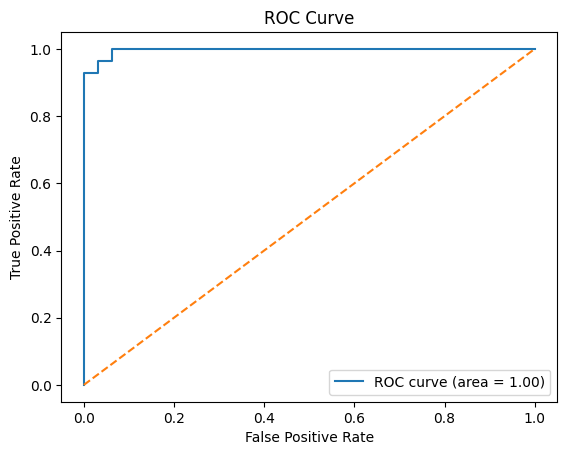

AUC Score: 0.9966517857142857


In [12]:
# Cell 11: ROC Curve

fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label="ROC curve (area = %0.2f)" % roc_auc)
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend(loc="lower right")
plt.show()

print("AUC Score:", roc_auc)